### Procesamiento de Lenguaje Natural I
# **Desafío 1**



In [75]:
%pip install numpy scikit-learn

### Vectorización de texto y modelo de clasificación Naïve Bayes con el dataset 20 newsgroups

In [76]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import f1_score

Utilizamos **20newsgroups** por ser un dataset clásico de NLP ya viene incluido y formateado en sklearn

In [77]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

## Carga de datos

Cargamos los datos (ya separados de forma predeterminada en train y test)

El dataset 20 Newsgroups contiene aproximadamente 18 000 publicaciones de grupos de noticias distribuidas en 20 temas. Está dividido en dos subconjuntos: uno para entrenamiento (train set) y otro para pruebas (test set).

In [78]:
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

## Vectorización

Instanciamos un vectorizador.

Podemos ver diferentes parámetros de instanciación en la documentación de sklearn https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [79]:
tfidfvect = TfidfVectorizer()

En el atributo `data` accedemos al texto

In [80]:
print(newsgroups_train.data[0])

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


Con la interfaz habitual de sklearn podemos ajustar el vectorizador (obtener el vocabulario y calcular el vector IDF) y transformar directamente los datos.

Podemos denominar `X_train` como la matriz documento-término.

In [81]:
X_train = tfidfvect.fit_transform(newsgroups_train.data)

Recordemos que las vectorizaciones por conteos son de tipo sparse, por ello sklearn convenientemente devuelve los vectores de documentos como matrices de tipo sparse.

In [82]:
print(type(X_train))
print(f'shape: {X_train.shape}')
print(f'Cantidad de documentos: {X_train.shape[0]}')
print(f'Tamaño del vocabulario (dimensionalidad de los vectores): {X_train.shape[1]}')

<class 'scipy.sparse._csr.csr_matrix'>
shape: (11314, 101631)
Cantidad de documentos: 11314
Tamaño del vocabulario (dimensionalidad de los vectores): 101631


Una vez ajustado el vectorizador, podemos acceder a atributos como el vocabulario aprendido. Es un diccionario que va de términos a índices.

El índice es la posición en el vector de documento.

In [83]:
tfidfvect.vocabulary_['car']

25775

Probamos con una palbra que no está en el documento.

Es muy útil tener el diccionario opuesto que va de índices a términos

In [84]:
idx2word = {v: k for k,v in tfidfvect.vocabulary_.items()}

En `y_train` guardamos los targets que son enteros

In [85]:
y_train = newsgroups_train.target
y_train[:10]

array([ 7,  4,  4,  1, 14, 16, 13,  3,  2,  4])

Hay 20 clases correspondientes a los 20 grupos de noticias

In [86]:
print(f'clases {np.unique(newsgroups_test.target)}')
newsgroups_test.target_names

clases [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

## Similaridad de documentos

Veamos similaridad de documentos. Tomemos algún documento

In [87]:
idx = 4811
print(newsgroups_train.data[idx])

THE WHITE HOUSE

                  Office of the Press Secretary
                   (Pittsburgh, Pennslyvania)
______________________________________________________________
For Immediate Release                         April 17, 1993     

             
                  RADIO ADDRESS TO THE NATION 
                        BY THE PRESIDENT
             
                Pittsburgh International Airport
                    Pittsburgh, Pennsylvania
             
             
10:06 A.M. EDT
             
             
             THE PRESIDENT:  Good morning.  My voice is coming to
you this morning through the facilities of the oldest radio
station in America, KDKA in Pittsburgh.  I'm visiting the city to
meet personally with citizens here to discuss my plans for jobs,
health care and the economy.  But I wanted first to do my weekly
broadcast with the American people. 
             
             I'm told this station first broadcast in 1920 when
it reported that year's presidential elec

Medimos la similaridad coseno con todos los documentos de train

In [88]:
cossim = cosine_similarity(X_train[idx], X_train)[0]

Podemos ver los valores de similaridad ordenados de mayor a menor

In [89]:
np.sort(cossim)[::-1]

array([1.        , 0.70930477, 0.67474953, ..., 0.        , 0.        ,
       0.        ])

Después vemos a qué documentos corresponden

In [90]:
np.argsort(cossim)[::-1]

array([4811, 6635, 4253, ..., 9019, 9016, 8748])

Obtenemos los 5 documentos más similares:

In [91]:
mostsim = np.argsort(cossim)[::-1][1:6]
print(mostsim)

[6635 4253 3596 4271 3746]


El documento original pertenece a la clase:

In [92]:
newsgroups_train.target_names[y_train[idx]]

'talk.politics.misc'

Revisamos las clases de los 5 más similares:

In [93]:
for i in mostsim:
  print(newsgroups_train.target_names[y_train[i]])

talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc


### Modelo de clasificación Naïve Bayes

Instanciamos el modelo de clasificación Naive Bayes y lo entrenamos con sklearn

In [94]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

MultinomialNB()

Ya tenemos nuestro vectorizador ya ajustado en train, vectorizamos los textos
del conjunto de test.

In [95]:
X_test = tfidfvect.transform(newsgroups_test.data)
y_test = newsgroups_test.target
y_pred =  clf.predict(X_test)

El F1-score es una métrica adecuada para evaluar el desempeño de modelos de clasificación, especialmente cuando existe desbalance entre clases.

* El promediado macro calcula el promedio del F1-score de cada clase, otorgando el mismo peso a todas las clases.
* El promediado micro calcula las métricas de forma global considerando todas las predicciones; en problemas de clasificación multiclase suele ser equivalente a la accuracy, por lo que no es la mejor métrica cuando el dataset está desbalanceado.

In [96]:
f1_score(y_test, y_pred, average='macro')

0.5854345727938506

---

## **Consigna del Desafío 1**
**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado.**



**1. Vectorizar documentos**
* Tomar 5 documentos al azar y medir similaridad con el resto de los documentos.
Estudiar los 5 documentos más similares de cada uno analizar si tiene sentido
la similaridad según el contenido del texto y la etiqueta de clasificación.

**2. Construir un modelo de clasificación por prototipos (tipo zero-shot).**
* Clasificar los documentos de un conjunto de test comparando cada uno con todos los de entrenamiento y asignar la clase al label del documento del conjunto de entrenamiento con mayor similaridad.

**3. Entrenar modelos de clasificación Naïve Bayes para maximizar el desempeño de clasificación**

* F1-Score Macro en el conjunto de datos de test. Considerar cambiar parámetros
de instanciación del vectorizador y los modelos y probar modelos de Naïve Bayes Multinomial y ComplementNB.

**NO cambiar el hiperparámetro ngram_range de los vectorizadores**.

**4. Transponer la matriz documento-término.**
* De esa manera se obtiene una matriz término-documento que puede ser interpretada como una colección de vectorización de palabras.
* Estudiar ahora similaridad entre palabras tomando 5 palabras y estudiando sus 5 más similares.

**Elegir las palabras MANUALMENTE para evitar la aparición de términos poco interpretables**.


## 1 - Vectorización de documentos y comparación

[3292 6252 9993 4499 2318]
          3292      6252      9993      4499      2318
3292  1.000000  0.040064  0.054601  0.038542  0.034800
6252  0.040064  1.000000  0.195169  0.145556  0.151603
9993  0.054601  0.195169  1.000000  0.231625  0.185360
4499  0.038542  0.145556  0.231625  1.000000  0.185623
2318  0.034800  0.151603  0.185360  0.185623  1.000000


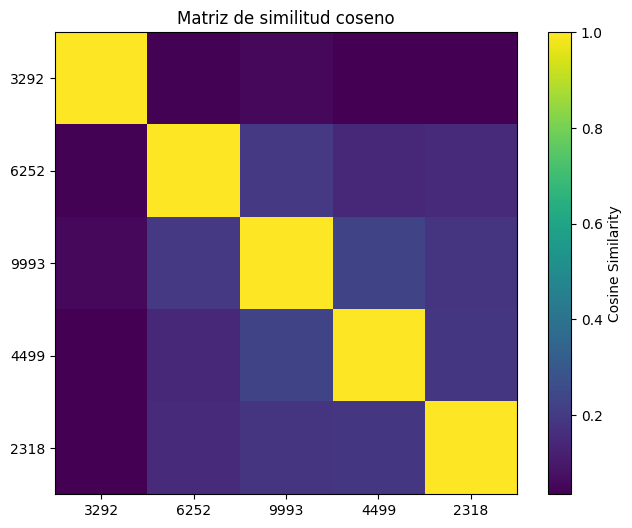

In [97]:
# definimos 5 idx aleatorios con un random seed: 178
np.random.seed(178)
idx = np.random.randint(0, X_train.shape[0]-1, 5)
print(idx)

from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# matriz de similitud coseno
cossim_matrix = cosine_similarity(X_train[idx])

# dataframe para verla más prolija
df_cossim = pd.DataFrame(
    cossim_matrix,
    index=idx,
    columns=idx
)

print(df_cossim)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(cossim_matrix)
plt.colorbar(label='Cosine Similarity')
plt.xticks(range(len(idx)), idx)
plt.yticks(range(len(idx)), idx)
plt.title('Matriz de similitud coseno')
plt.show()

Según la matríz de similitud cosenoidal los pares de documentos mas parecidos son: (4499,9993), (2318,4499), (2318,9993), con 0.23, 0.19 y 0.18 respectivamente. La primera sensación es que tiene sentido que los pares de documentos con mas similitud es la combinatoria de los 3 documentos.

Procedemos a la visualización de estos documentos.

In [98]:
# comparacion de documentos
for i in idx:
  print("")
  print("="*100)
  print("")
  print(f'Documento {i}')
  print(newsgroups_train.data[i])



Documento 3292

No flames please, but I picked up this discussion a bit late and I 
am really curious...

What exactly *is* the $25 network?
Something to hack together N serial cables?
Something with N serial drivers?


Documento 6252
ATTN: Those who live inthe Philadelphia Metro area...

Back in September I was listening to WIP, and I remember the morning
guys were talking with Mayor Ed Rendell.  The topic of conversation
was a new ball park for the Phillies.  The location for this new park
was suggested to be near 30th St Station.  At the time, the mayor was
optimisitic that in the future this could become a reality.  Has
there been any new news on this subject or is it still a pipe dream?
I know the city of Philadelphia has other projects ahead, such as the
new convention center and the upcoming Spectrum II.  But it would be
nice to see this a reality.  It is planned that the Phillies leave
the VET and leave it solely to the Eagles (and if that's the case,
the Eagles should make t

In [99]:
# Veamos la categoria de estos documentos
for i in idx:
  print(f'Categoria del documento {i}: {newsgroups_train.target_names[y_train[i]]}')

Categoria del documento 3292: sci.electronics
Categoria del documento 6252: rec.sport.baseball
Categoria del documento 9993: talk.religion.misc
Categoria del documento 4499: sci.crypt
Categoria del documento 2318: talk.politics.mideast


Si bien los documentos no coinciden en categoría podemos entender que Política, religión y "Economía" (Si tomaramos esto por crypto), que por ejemplo usa terminos como "Ammendment" comunmente asociados a política, pueden tener mas relación entre ellos que con electrónica o baseball.

## 2 - Clasificación zero-shot

In [100]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# matriz completa de similitudes
S = cosine_similarity(X_test, X_train)

# para cada test, índice del train más similar
best_idx = np.argmax(S, axis=1)

# predicciones
preds = y_train[best_idx]

# accuracy
acc = np.mean(preds == y_test)

print(acc)

0.5088953797132236


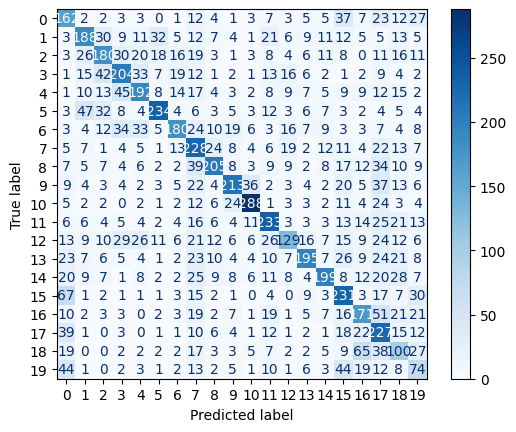

In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# matriz de confusión
cm = confusion_matrix(y_test, preds)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.show()

In [102]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, preds, average="macro")

print("F1 macro:", f1)

F1 macro: 0.5049911553681621


## 3 - NB Multinomial

In [103]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import f1_score

alphas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0]

vectorizers = [
    {
        "min_df": 1,
        "max_df": 1.0
    },
    {
        "min_df": 2,
        "max_df": 0.95
    },
    {
        "min_df": 5,
        "max_df": 0.9
    }
]

models = [
    ("MultinomialNB", MultinomialNB),
    ("ComplementNB", ComplementNB)
]

best_f1 = 0
best_config = None

for vec_params in vectorizers:

    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words=None,
        sublinear_tf=True,
        **vec_params
    )

    Xtr = vectorizer.fit_transform(newsgroups_train.data)
    Xte = vectorizer.transform(newsgroups_test.data)

    for model_name, ModelClass in models:

        for alpha in alphas:

            model = ModelClass(alpha=alpha)

            model.fit(Xtr, y_train)

            preds = model.predict(Xte)

            f1 = f1_score(
                y_test,
                preds,
                average="macro"
            )

            print(
                model_name,
                alpha,
                vec_params,
                f1
            )

            if f1 > best_f1:
                best_f1 = f1
                best_config = (
                    model_name,
                    alpha,
                    vec_params
                )

print("\nBEST:")
print(best_config)
print(best_f1)

MultinomialNB 0.01 {'min_df': 1, 'max_df': 1.0} 0.6787204282508428
MultinomialNB 0.05 {'min_df': 1, 'max_df': 1.0} 0.665766525560479
MultinomialNB 0.1 {'min_df': 1, 'max_df': 1.0} 0.6572004919892916
MultinomialNB 0.2 {'min_df': 1, 'max_df': 1.0} 0.6402761518135431
MultinomialNB 0.3 {'min_df': 1, 'max_df': 1.0} 0.6317478299898632
MultinomialNB 0.4 {'min_df': 1, 'max_df': 1.0} 0.6246521663238684
MultinomialNB 0.5 {'min_df': 1, 'max_df': 1.0} 0.6151221921642548
MultinomialNB 1.0 {'min_df': 1, 'max_df': 1.0} 0.5859647447228136
ComplementNB 0.01 {'min_df': 1, 'max_df': 1.0} 0.6635943543567087
ComplementNB 0.05 {'min_df': 1, 'max_df': 1.0} 0.6858371312138153
ComplementNB 0.1 {'min_df': 1, 'max_df': 1.0} 0.6926823186826047
ComplementNB 0.2 {'min_df': 1, 'max_df': 1.0} 0.6994500640906747
ComplementNB 0.3 {'min_df': 1, 'max_df': 1.0} 0.6989825595098211
ComplementNB 0.4 {'min_df': 1, 'max_df': 1.0} 0.6978029546503332
ComplementNB 0.5 {'min_df': 1, 'max_df': 1.0} 0.6967616024380747
ComplementNB 1

## 4 - Transponer matríz documento término

In [113]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# IMPORTANTE
X_terms = X_train.T

terms = tfidfvect.get_feature_names_out()

print(X_terms.shape)
print(len(terms))

def similar_words(word, X_terms, terms, topk=5):

    idx = np.where(terms == word)[0][0]

    sims = cosine_similarity(
        X_terms[idx],
        X_terms
    ).flatten()

    best = np.argsort(sims)[::-1][1:topk+1]

    return terms[best]

(101631, 11314)
101631


In [116]:
words = ["pizza", "government", "nice", "film", "love"]

for w in words:
    print("\n", w)
    print(similar_words(w, X_terms, terms))


 pizza
['casserole' 'tlu' 'gic' 'truelove' 'leftover']

 government
['the' 'to' 'of' 'libertarian' 'encryption']

 nice
['err' 'to' 'it' 'and' 'copped']

 film
['prototype' '_how' 'germ' 'spacesuits' 'crystalline']

 love
['davem' 'innappropriate' 'clanging' 'multitude' 'mielke']


Los resultados no son tan satisfactorios, las mejores siendo "pizza" que tiene alguna relaciión con 'casserole' o 'leftover', "government" pero nice, film y love no tienen demasiada relación con las palabras que se traen.

Esto probablemente se debe a que el modelo de TF-IDF no captura semántica de las palabras si no solo frecuencia estadística.